In [1]:
import sys
sys.path.append('../../utils/')

In [2]:
from Bias_Variance_Estimator import estimate_bias_variance

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [5]:
def true_function(x):
    return torch.sin(2 * torch.pi * x)

def generate_dataset(n_samples=50, noise_std=0.1):
    x = torch.rand(n_samples, 1)
    y = true_function(x) + torch.randn_like(x) * noise_std
    return x, y

In [6]:
def plot_dataset(x_train, y_train, true_func=true_function, n_points=200):
    # Plot true function
    x_true = torch.linspace(0, 1, n_points).unsqueeze(1)
    y_true = true_func(x_true)

    plt.figure(figsize=(6, 4))
    plt.plot(x_true.numpy(), y_true.numpy(), label='True Function', color='black')
    plt.scatter(x_train.numpy(), y_train.numpy(), color='blue', label='Noisy Samples', alpha=0.7)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Noisy Dataset vs. True Function')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [7]:
X, y = generate_dataset(n_samples=50, noise_std=0.1)

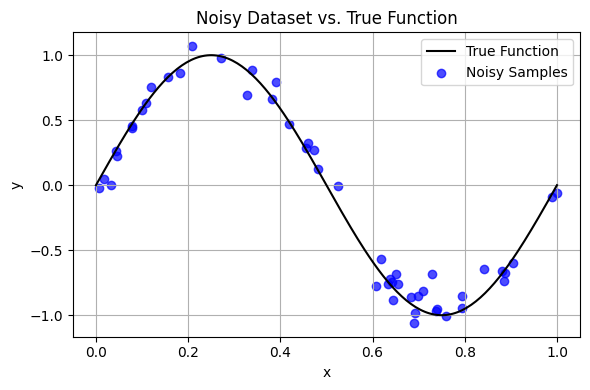

In [8]:
plot_dataset(X,y,true_function)

In [9]:
X_train,X_test,y_train,y_test = train_test_split(X.numpy(),y.numpy(),test_size = 0.25,random_state=42)

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
## Converting to pytorch tensors
X_train_tensor = torch.tensor(X_train_scaled,dtype = torch.float32)
y_train_tensor = torch.tensor(y_train,dtype = torch.float32).view(-1,1)
X_test_tensor = torch.tensor(X_test_scaled,dtype = torch.float32)
y_test_tensor = torch.tensor(y_test,dtype = torch.float32).view(-1,1)

In [12]:
## Creating dataloaders
train_dataset = TensorDataset(X_train_tensor,y_train_tensor)
test_dataset = TensorDataset(X_test_tensor,y_test_tensor)

train_loader = DataLoader(train_dataset,batch_size=64,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=64)

In [13]:
def train_model(model,train_loader,epochs=20,lr=0.001):
    loss = nn.L1Loss()
    optimizer = optim.Adam(model.parameters(),lr=lr)
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for X_batch,y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            l = loss(outputs,y_batch)
            l.backward()
            optimizer.step()
            running_loss+=l.item()*X_batch.size(0) ## stores the entire loss during an epoch

        cur_epoch_loss = running_loss/len(train_loader.dataset)
        print(f"Epoch {epoch+1}, Loss: {cur_epoch_loss:.4f}")

In [14]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
def evaluate_model(model, test_loader):
    model.eval()
    mse_loss = nn.L1Loss()
    total_loss = 0.0
    all_preds=[]
    all_targets = []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            preds = model(X_batch)
            loss = mse_loss(preds, y_batch)
            all_preds.append(preds)
            all_targets.append(y_batch)
            total_loss += loss.item() * X_batch.size(0)
    all_preds = torch.cat(all_preds).squeeze().numpy()
    all_targets = torch.cat(all_targets).squeeze().numpy()

    mse = mean_squared_error(all_targets, all_preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(all_targets, all_preds)
    r2 = r2_score(all_targets, all_preds)
    print(f"MSE:  {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"R²:   {r2:.4f}")
    print(f"Test MSE: {total_loss / len(test_loader.dataset):.4f}")

In [15]:
class PolynomialRegression(nn.Module):
    def __init__(self,degree:int):
        super(PolynomialRegression,self).__init__()
        self.degree = degree
        self.linear = nn.Linear(degree+1,1)
    def forward(self, x):
        # x: shape [batch_size, 1]
        # Create polynomial features: [x^0, x^1, ..., x^degree]
        poly_features = torch.cat([x ** i for i in range(self.degree + 1)], dim=1)
        return self.linear(poly_features)

In [16]:
input_dim = X_train.shape[1]
model = PolynomialRegression(degree=3)
train_model(model, train_loader, epochs=20)

Epoch 1, Loss: 1.2141
Epoch 2, Loss: 1.2117
Epoch 3, Loss: 1.2092
Epoch 4, Loss: 1.2068
Epoch 5, Loss: 1.2044
Epoch 6, Loss: 1.2020
Epoch 7, Loss: 1.1996
Epoch 8, Loss: 1.1972
Epoch 9, Loss: 1.1948
Epoch 10, Loss: 1.1924
Epoch 11, Loss: 1.1899
Epoch 12, Loss: 1.1875
Epoch 13, Loss: 1.1851
Epoch 14, Loss: 1.1827
Epoch 15, Loss: 1.1803
Epoch 16, Loss: 1.1779
Epoch 17, Loss: 1.1755
Epoch 18, Loss: 1.1731
Epoch 19, Loss: 1.1707
Epoch 20, Loss: 1.1682


In [17]:
evaluate_model(model, test_loader)

MSE:  1.3527
RMSE: 1.1631
MAE:  1.1017
R²:   -1.3177
Test MSE: 1.1017


In [16]:
estimate_bias_variance(
    model_class=PolynomialRegression,# or any nn.Module class
    loss_fn=nn.MSELoss(),
    model_kwargs={'degree': 5},
    X_train=X_train_scaled,
    y_train=y_train,
    X_test=X_test_scaled,
    y_test=y_test,
    num_models=20,
    lr=0.001,
    batch_size=64
    
)

Starting experiment with 20 models...

--- Training Model 1/20 ---
Epoch 1/100, Avg Train Loss: 1.8813, Val Loss: 3.7910
Epoch 2/100, Avg Train Loss: 1.8601, Val Loss: 3.8049
Epoch 3/100, Avg Train Loss: 1.8391, Val Loss: 3.8189
Epoch 4/100, Avg Train Loss: 1.8184, Val Loss: 3.8329
Epoch 5/100, Avg Train Loss: 1.7980, Val Loss: 3.8468
Epoch 6/100, Avg Train Loss: 1.7778, Val Loss: 3.8608
Epoch 7/100, Avg Train Loss: 1.7579, Val Loss: 3.8747
Epoch 8/100, Avg Train Loss: 1.7383, Val Loss: 3.8886
Epoch 9/100, Avg Train Loss: 1.7189, Val Loss: 3.9024
Epoch 10/100, Avg Train Loss: 1.6997, Val Loss: 3.9161
Epoch 11/100, Avg Train Loss: 1.6809, Val Loss: 3.9297
Early stopping triggered after 11 epochs.

--- Training Model 2/20 ---
Epoch 1/100, Avg Train Loss: 4.5349, Val Loss: 4.9307


E:\Dissertation_bv\regression\MSE\../../utils\Bias_Variance_Estimator.py:103: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_model.pt')

Epoch 2/100, Avg Train Loss: 4.4618, Val Loss: 4.8554
Epoch 3/100, Avg Train Loss: 4.3895, Val Loss: 4.7810
Epoch 4/100, Avg Train Loss: 4.3178, Val Loss: 4.7074
Epoch 5/100, Avg Train Loss: 4.2470, Val Loss: 4.6346
Epoch 6/100, Avg Train Loss: 4.1769, Val Loss: 4.5627
Epoch 7/100, Avg Train Loss: 4.1075, Val Loss: 4.4916
Epoch 8/100, Avg Train Loss: 4.0390, Val Loss: 4.4214
Epoch 9/100, Avg Train Loss: 3.9712, Val Loss: 4.3521
Epoch 10/100, Avg Train Loss: 3.9043, Val Loss: 4.2836
Epoch 11/100, Avg Train Loss: 3.8381, Val Loss: 4.2161
Epoch 12/100, Avg Train Loss: 3.7728, Val Loss: 4.1494
Epoch 13/100, Avg Train Loss: 3.7083, Val Loss: 4.0837
Epoch 14/100, Avg Train Loss: 3.6446, Val Loss: 4.0188
Epoch 15/100, Avg Train Loss: 3.5818, Val Loss: 3.9549
Epoch 16/100, Avg Train Loss: 3.5198, Val Loss: 3.8919
Epoch 17/100, Avg Train Loss: 3.4587, Val Loss: 3.8298
Epoch 18/100, Avg Train Loss: 3.3984, Val Loss: 3.7687
Epoch 19/100, Avg Train Loss: 3.3390, Val Loss: 3.7085
Epoch 20/100, Avg 

ValueError: need at least one array to stack